# Data Evaluation: Demographics and Questionnaires

data preprocessing steps:
- added column "Whiteboard Experience Codified" (1/0)
- renamed columns with comparison questions (full question text -> CQ-1/CQ-2/CQ-3/CQ-4)
- education (B-GE, B-I, ?, M-I, D-I, M-GE, M-BI)

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

data_df = pd.read_csv('../ma-eval/questionnaire-responses-preprocessed.csv')
data_df

,Timestamp,Participant ID,Age,Gender,Education (study course and whether its ongoing),Education Codified,Occupation:,Number of projects/games you worked on (rough estimate),Projects Codified,"Experience with digital whiteboards (e.g. Miro, Figjam)",...,UEQS-4,UEQS-5,UEQS-6,UEQS-7,UEQS-8,C-Q1,C-Q2,C-Q3,C-Q4,FQ2
0,6/29/2026 22:39:09,MA12534,24,Female,Bachelor (Games Engineering),B-GE,Student,5,5,used Miro,...,3,6,7,7,7,3,1,2,4,NaN
1,7/7/2026 11:50:30,MA26593,22,Female,B.Sc. Informatics: Games Engineering (complete...,B-GE B-I,Student,1,1,NaN,...,3,5,6,7,6,3,4,4,4,NaN
2,7/1/2026 17:53:04,MA34230,20,Male,B.Sc. Games Engineering,B-GE,Student,3,3,Miro and Milanote,...,6,6,6,7,7,2,4,4,5,The locks need to be differentiable by look
3,6/30/2026 11:53:04,MA7125,21,Prefer not to say,ongoing,?,"Student, HiWi",1,1,"not those examples, but I used ""FreeForm""",...,6,5,7,5,5,5,4,5,5,NaN
4,7/2/2026 15:56:41,MA95137,26,Prefer not to say,Bachelor Games Engineering (ongoing),B-GE,Student,5+ (but always only small projects for uni or ...,5,basically none,...,2,7,7,6,5,5,4,4,5,It's nice to use but it takes some time to get...
5,6/30/2026 16:53:41,MA95935,20,Female,ongoing bachelor,?,Student,"completed: 5, ongoing: 3",5,Miro,...,7,7,7,4,4,5,5,5,5,"Would have liked to have a ""total time needed ..."
6,7/2/2026 13:55:20,MB10509,25,Male,M.Sc. Informatics (completed),M-I,unemployed,3,3,none,...,7,7,7,5,5,3,5,5,4,Tool did not make it clear which locks had whi...
7,6/30/2026 13:55:53,MB24145,22,Male,ongoing,?,Student,4-5,5,fast gar keine,...,3,6,6,4,5,4,4,4,4,Please for gods sake put more contrast between...
8,7/7/2026 16:02:18,MB41880,28,Male,Currently in msc. informatics,M-I,"student, web dev",3,3,non zero but close,...,4,3,5,2,2,2,1,4,3,I feel like so much potential is wasted not in...
9,7/1/2026 11:58:13,MB50964,21,Female,"B.Sc. Games Engineering, 4th semester",B-GE,student,5,5,"mediocre, not new but also not experienced",...,5,7,7,6,6,4,4,4,5,i wasn't really sure what happened in the path...


## Demographics

<Axes: >

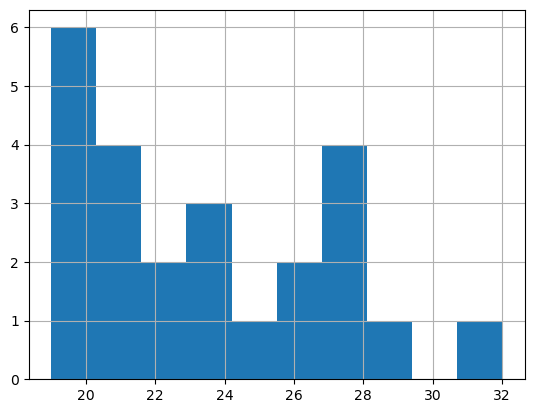

In [3]:
data_df['Age'].hist()

In [4]:
data_df['Age'].describe()

count    24.000000
mean     23.625000
std       3.669054
min      19.000000
25%      20.750000
50%      23.000000
75%      26.250000
max      32.000000
Name: Age, dtype: float64

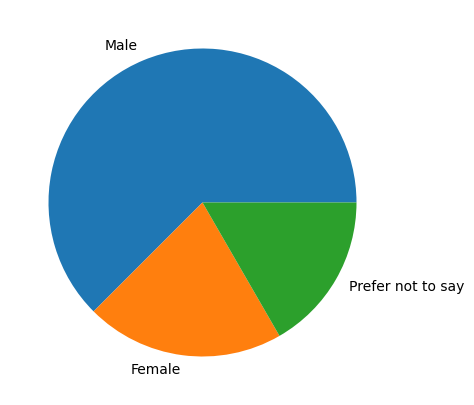

In [5]:
gender_counts = data_df['Gender'].value_counts(normalize=True)
plot = gender_counts.plot.pie(y="count", figsize=(5, 5))

In [6]:
gender_counts

Gender
Male                 0.625000
Female               0.208333
Prefer not to say    0.166667
Name: proportion, dtype: float64

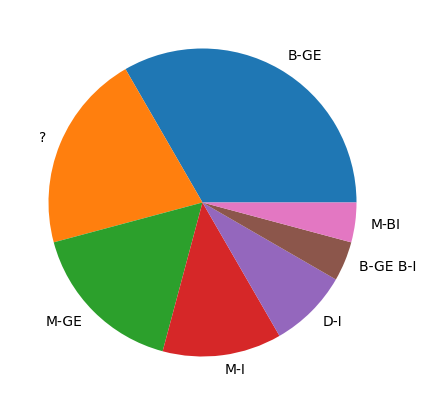

In [7]:
edu_counts = data_df['Education Codified'].value_counts(normalize=True)
plot = edu_counts.plot.pie(y="count", figsize=(5, 5))

<Axes: >

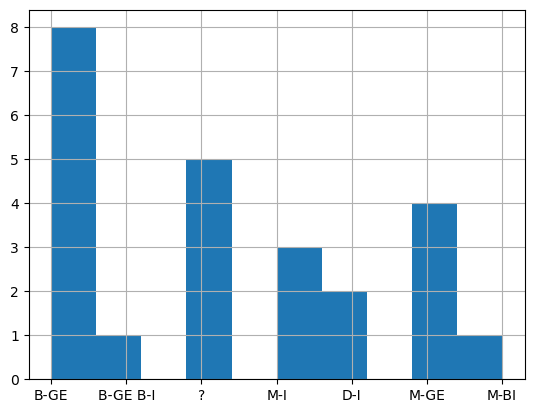

In [8]:
data_df['Education Codified'].hist()

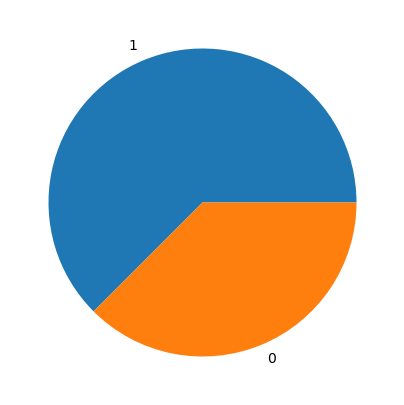

In [9]:
whiteboard_counts = data_df['Whiteboard Experience Codified'].value_counts(normalize=True)
plot = whiteboard_counts.plot.pie(y="count", figsize=(5, 5))

In [10]:
whiteboard_counts

Whiteboard Experience Codified
1    0.625
0    0.375
Name: proportion, dtype: float64

In [11]:
data_df[['Age', 'Whiteboard Experience Codified']].corr()

,Age,Whiteboard Experience Codified
Age,1.000000,-0.272566
Whiteboard Experience Codified,-0.272566,1.000000


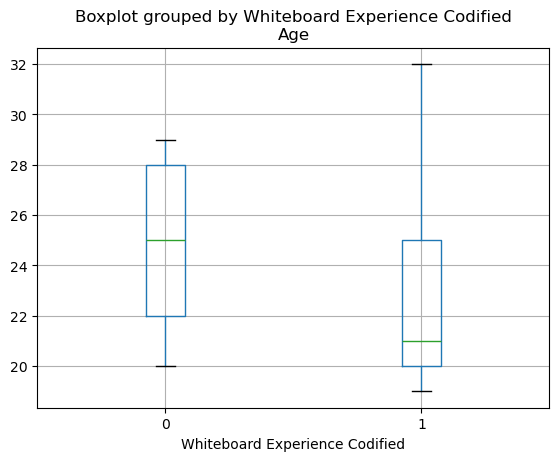

In [12]:
ax1 = data_df.boxplot(column=['Age'], by='Whiteboard Experience Codified')

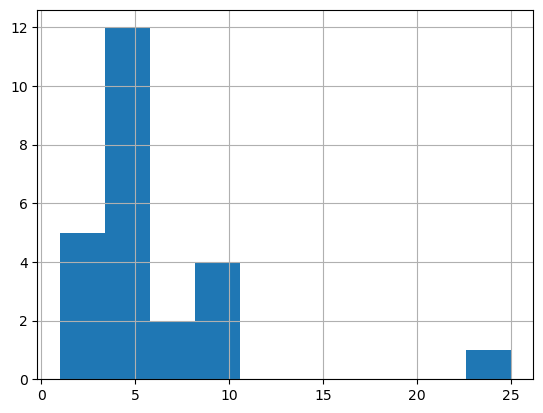

In [13]:
project_counts = data_df['Projects Codified'].hist()

In [14]:
data_df['Projects Codified'].describe()

count    24.000000
mean      6.083333
std       4.772354
min       1.000000
25%       4.000000
50%       5.000000
75%       6.250000
max      25.000000
Name: Projects Codified, dtype: float64

In [15]:
data_df[['Whiteboard Experience Codified', 'Projects Codified']].corr()

,Whiteboard Experience Codified,Projects Codified
Whiteboard Experience Codified,1.000000,0.216461
Projects Codified,0.216461,1.000000


## Miro Comparison Questions

1. Compared to Miro, the system made it easier to analyze dungeon designs.
2. Compared to Miro, I felt more confident in my answers.
3. Compared to Miro, I was able to complete the tasks more efficiently.
4. If I were analyzing game levels in practice, I would prefer using the system over a general-purpose whiteboard

In [16]:
comparison_columns = [
    "C-Q1",
    "C-Q2",
    "C-Q3",
    "C-Q4"
]

compared_df = data_df[comparison_columns]
compared_df

,C-Q1,C-Q2,C-Q3,C-Q4
0,3,1,2,4
1,3,4,4,4
2,2,4,4,5
3,5,4,5,5
4,5,4,4,5
5,5,5,5,5
6,3,5,5,4
7,4,4,4,4
8,2,1,4,3
9,4,4,4,5


In [17]:
compared_df.describe()

,C-Q1,C-Q2,C-Q3,C-Q4
count,24.000000,24.000000,24.000000,24.000000
mean,3.208333,3.583333,3.875000,4.041667
std,1.284664,1.282547,1.115601,1.082636
min,1.000000,1.000000,2.000000,2.000000
25%,2.000000,2.750000,3.750000,3.000000
50%,3.000000,4.000000,4.000000,4.000000
75%,4.250000,4.250000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000


<Axes: >

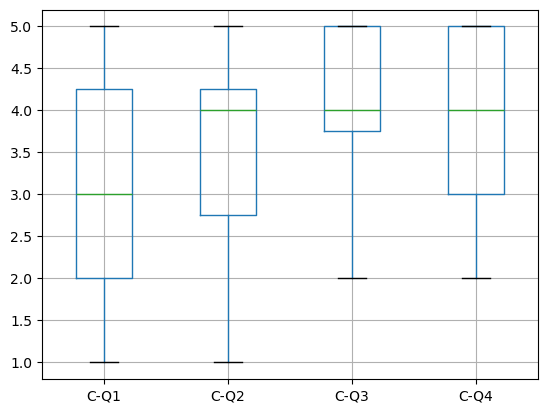

In [18]:
compared_df.boxplot()

Text(0.5, 0.98, '')

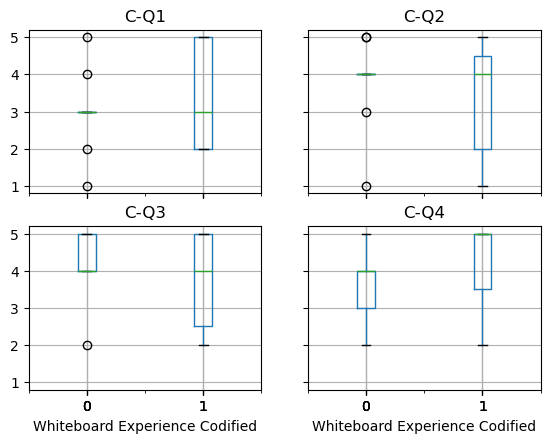

In [19]:
data_df.boxplot(column=comparison_columns, by="Whiteboard Experience Codified")
plt.suptitle('')

array([[<Axes: title={'center': 'C-Q1'}>,
        <Axes: title={'center': 'C-Q2'}>,
        <Axes: title={'center': 'C-Q3'}>,
        <Axes: title={'center': 'C-Q4'}>]], dtype=object)

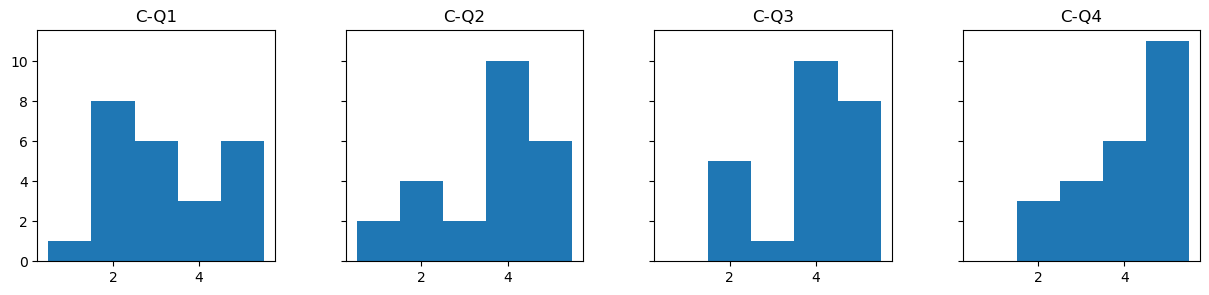

In [21]:
cq_hist = data_df.hist(column=comparison_columns, bins=np.arange(0,6)+0.5, grid=False, layout=(1, 4), figsize=(15, 3), sharey=True )
cq_hist[0][1].yaxis.get_label().set_visible(True)
cq_hist

array([[<Axes: title={'center': 'C-Q1'}, xlabel='Whiteboard Experience Codified'>,
        <Axes: title={'center': 'C-Q2'}, xlabel='Whiteboard Experience Codified'>],
       [<Axes: title={'center': 'C-Q3'}, xlabel='Whiteboard Experience Codified'>,
        <Axes: title={'center': 'C-Q4'}, xlabel='Whiteboard Experience Codified'>]],
      dtype=object)

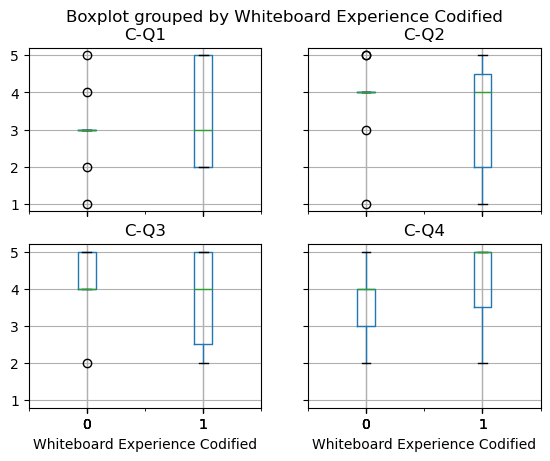

In [ ]:
data_df.boxplot(column=comparison_columns, by='Whiteboard Experience Codified')

### Compared to Miro, the system made it easier to analyze dungeon designs.

<Axes: >

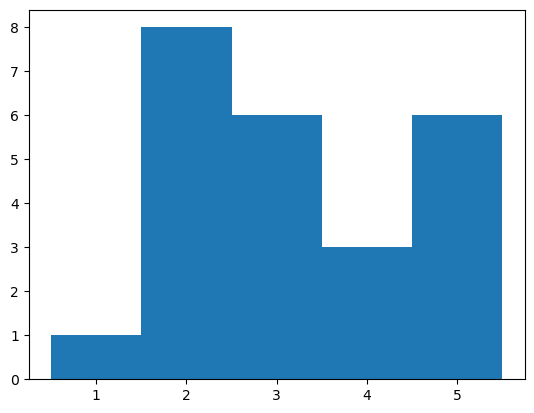

In [ ]:
compared_df["C-Q1"].hist(bins=np.arange(0,6)+0.5, grid=False)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

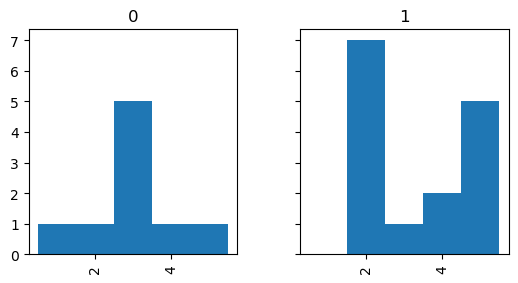

In [ ]:
data_df.hist(column=["C-Q1"], bins=np.arange(0,6)+0.5, grid=False, by="Whiteboard Experience Codified", figsize=(6,3), sharey=True)

### Compared to Miro, I felt more confident in my answers.

<Axes: >

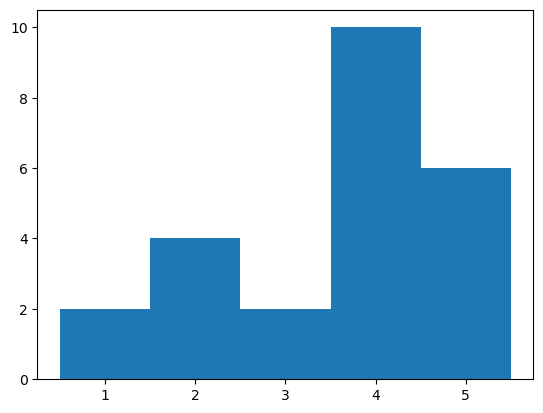

In [ ]:
compared_df["C-Q2"].hist(bins=np.arange(0,6)+0.5, grid=False)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

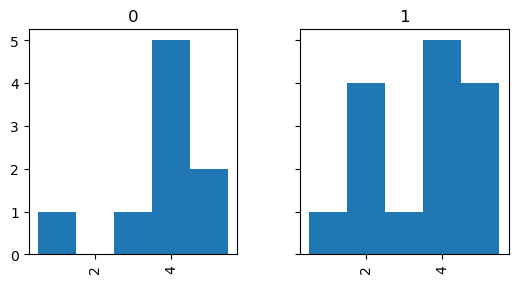

In [ ]:
data_df.hist(column=["C-Q2"], bins=np.arange(0,6)+0.5, grid=False, by="Whiteboard Experience Codified", figsize=(6, 3), sharey=True)

### Compared to Miro, I was able to complete the tasks more efficiently.

<Axes: >

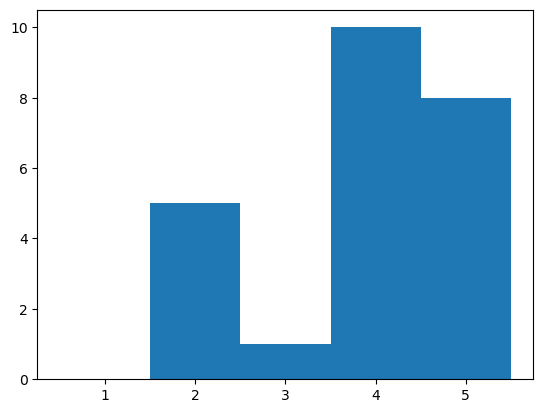

In [ ]:
compared_df["C-Q3"].hist(bins=np.arange(0,6)+0.5, grid=False)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

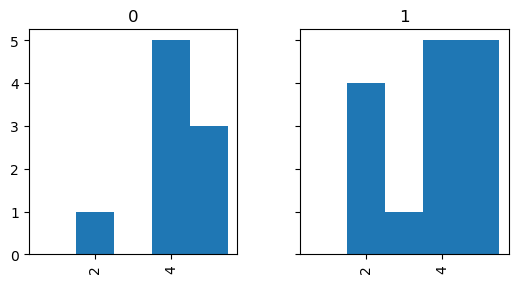

In [ ]:
data_df.hist(column=["C-Q3"], bins=np.arange(0,6)+0.5, grid=False, by="Whiteboard Experience Codified", figsize=(6, 3), sharey=True)

### Compared to Miro, I was able to complete the tasks more efficiently.

<Axes: >

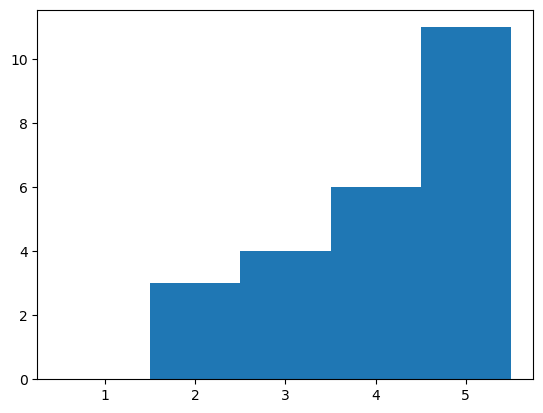

In [ ]:
compared_df["C-Q4"].hist(bins=np.arange(0,6)+0.5, grid=False)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

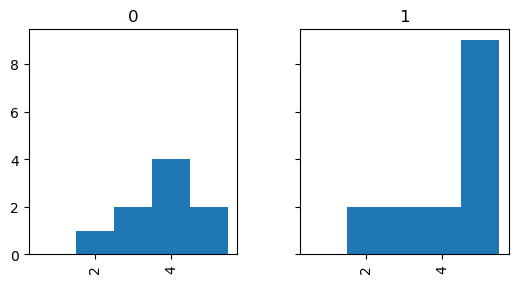

In [ ]:
data_df.hist(column=["C-Q4"], bins=np.arange(0,6)+0.5, grid=False, by="Whiteboard Experience Codified", figsize=(6, 3), sharey=True)

### Answer Distributions By Whiteboard Experience

In [ ]:
from scipy.stats import wilcoxon, mannwhitneyu, levene, ttest_ind
import numpy as np
np.set_printoptions(legacy='1.25')

In [ ]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

#### C-Q1

*x*: C-Q1 answers *with* whiteboard experience

*y*: C-Q1 *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_c_q1_wb_exp = mannwhitneyu(data_exp_yes['C-Q1'], data_exp_no['C-Q1'], alternative='less')
mwu_c_q1_wb_exp.statistic, mwu_c_q1_wb_exp.pvalue

(72.5, 0.6330103432972131)

In [ ]:
data_exp_yes['C-Q1'].median()

3.0

In [ ]:
data_exp_no['C-Q1'].median()

3.0

In [ ]:
lev_c_q1_wb_exp = levene(data_exp_yes['C-Q1'], data_exp_no['C-Q1'])
lev_c_q1_wb_exp.statistic, lev_c_q1_wb_exp.pvalue

(4.074695121951221, 0.05588339886619132)

#### C-Q2

*x*: C-Q2 answers *with* whiteboard experience

*y*: C-Q2 *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_c_q2_wb_exp = mannwhitneyu(data_exp_yes['C-Q2'], data_exp_no['C-Q2'], alternative='less')
mwu_c_q2_wb_exp.statistic, mwu_c_q2_wb_exp.pvalue

(60.5, 0.3420826661760219)

In [ ]:
data_exp_yes['C-Q2'].median()

4.0

In [ ]:
data_exp_no['C-Q2'].median()

4.0

In [ ]:
lev_c_q2_wb_exp = levene(data_exp_yes['C-Q2'], data_exp_no['C-Q2'])
lev_c_q2_wb_exp.statistic, lev_c_q2_wb_exp.pvalue

(0.9458598726114652, 0.3413479699753748)

#### C-Q3

*x*: C-Q3 answers *with* whiteboard experience

*y*: C-Q3 *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_c_q3_wb_exp = mannwhitneyu(data_exp_yes['C-Q3'], data_exp_no['C-Q3'], alternative='less')
mwu_c_q3_wb_exp.statistic, mwu_c_q3_wb_exp.pvalue

(58.0, 0.28396903114234606)

In [ ]:
data_exp_yes['C-Q3'].median()

4.0

In [ ]:
data_exp_no['C-Q3'].median()

4.0

In [ ]:
lev_c_q3_wb_exp = levene(data_exp_yes['C-Q3'], data_exp_no['C-Q3'])
lev_c_q3_wb_exp.statistic, lev_c_q3_wb_exp.pvalue

(1.342483108108108, 0.2590195018943345)

#### C-Q4

*x*: C-Q4 answers *with* whiteboard experience

*y*: C-Q4 *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_c_q4_wb_exp = mannwhitneyu(data_exp_yes['C-Q4'], data_exp_no['C-Q4'], alternative='greater')
mwu_c_q4_wb_exp.statistic, mwu_c_q4_wb_exp.pvalue

(87.0, 0.11397889086301405)

In [ ]:
data_exp_yes['C-Q4'].median()

5.0

In [ ]:
data_exp_no['C-Q4'].median()

4.0

In [ ]:
lev_c_q4_wb_exp = levene(data_exp_yes['C-Q4'], data_exp_no['C-Q4'])
lev_c_q4_wb_exp.statistic, lev_c_q4_wb_exp.pvalue

(0.09821428571428581, 0.7569351000940435)

In [ ]:
welchs_c_q4_wb_exp = ttest_ind(data_exp_yes['C-Q4'], data_exp_no['C-Q4'], equal_var=False, alternative='greater')
welchs_c_q4_wb_exp.statistic, welchs_c_q4_wb_exp.pvalue

(0.9621905154488819, 0.1739389403552342)